In [1]:
%pip install PyWavelets antropy --quiet

Note: you may need to restart the kernel to use updated packages.


# Модифицированный пайплайн c RandomForestClassifier для дыхания, SpO2 и PPG (стадии N1 и N2 объединили в light sleep)

In [2]:
import numpy as np
import pandas as pd
import mne
from scipy import signal
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
import antropy as ant

In [4]:
# ------------------------------------------------------------
# 1. Функции загрузки, предобработки и извлечения признаков
# ------------------------------------------------------------

def load_edf_signals(edf_path, channels):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_channels(channels)
    sfreq = raw.info['sfreq']
    signals = {ch: raw[ch][0].flatten() for ch in channels}
    return raw, signals, sfreq

def preprocess_signal(data, sfreq, lowcut=0.1, highcut=10, order=4):
    nyquist = 0.5 * sfreq
    low = lowcut / nyquist
    high = highcut / nyquist
    if low <= 0 or low >= high:
        b, a = signal.butter(order, high, btype='low')
    else:
        b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

def resample_signal(data, orig_sfreq, target_sfreq):
    if orig_sfreq == target_sfreq:
        return data
    num_samples = int(len(data) * target_sfreq / orig_sfreq)
    return signal.resample(data, num_samples)

def detect_resp_rate(resp_signal, sfreq):
    min_distance = int(2 * sfreq)
    peaks, _ = find_peaks(resp_signal, distance=min_distance, prominence=np.std(resp_signal)*0.2)
    if len(peaks) < 2:
        return np.nan
    intervals = np.diff(peaks) / sfreq
    return 60 / np.mean(intervals)

def detect_heart_rate(ppg_signal, sfreq):
    low = 0.5 / (sfreq/2)
    high = 5.0 / (sfreq/2)
    b, a = signal.butter(2, [low, high], btype='band')
    filtered_ppg = signal.filtfilt(b, a, ppg_signal)
    min_distance = int(0.5 * sfreq)
    peaks, _ = find_peaks(filtered_ppg, distance=min_distance, prominence=np.std(filtered_ppg)*0.5)
    if len(peaks) < 2:
        return np.nan, np.nan, np.nan, np.nan
    rr_intervals = np.diff(peaks) / sfreq
    heart_rate = 60 / np.mean(rr_intervals)
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals)**2))
    sdnn = np.std(rr_intervals)
    nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05)
    pnn50 = nn50 / len(rr_intervals) * 100
    return heart_rate, rmssd, sdnn, pnn50

def extract_features_from_window(window_signals, sfreq, channel_names):
    features = {}
    for ch in channel_names:
        data = window_signals[ch]
        if ch.startswith('RESP Breath'):
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            features[f'{ch}_min'] = np.min(data)
            features[f'{ch}_max'] = np.max(data)
            features[f'{ch}_p10'] = np.percentile(data, 10)
            features[f'{ch}_p90'] = np.percentile(data, 90)
            features[f'{ch}_slope'] = (data[-1] - data[0]) / len(data)
            resp_rate = detect_resp_rate(data, sfreq)
            features[f'{ch}_resp_rate'] = resp_rate if not np.isnan(resp_rate) else 0
            entropy = ant.spectral_entropy(data, sfreq, method='welch')
            features[f'{ch}_entropy'] = entropy
        elif ch == 'SAO2 SpO2':
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            features[f'{ch}_min'] = np.min(data)
            features[f'{ch}_desat_count_3pct'] = np.sum(np.diff(data) <= -3)
        elif ch == 'PPG':
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            hr, rmssd, sdnn, pnn50 = detect_heart_rate(data, sfreq)
            features[f'{ch}_heart_rate'] = hr if not np.isnan(hr) else 0
            features[f'{ch}_rmssd'] = rmssd if not np.isnan(rmssd) else 0
            features[f'{ch}_sdnn'] = sdnn if not np.isnan(sdnn) else 0
            features[f'{ch}_pnn50'] = pnn50 if not np.isnan(pnn50) else 0
    return features

def extract_epochs_dataset(raw, signals, sfreq, epoch_duration=30, 
                           channel_names=None, stage_mapping=None):
    """
    Извлекает эпохи и метки сна из аннотаций.
    stage_mapping: dict {строка_аннотации: числовая_метка}
    """
    if stage_mapping is None:
        stage_mapping = {
            'Sleep stage W(eventUnknown)': 0,
            'Sleep stage 1(eventUnknown)': 1,
            'Sleep stage 2(eventUnknown)': 1,   # N2 → Light
            'Sleep stage 3(eventUnknown)': 2,
            'Sleep stage R(eventUnknown)': 3,
    }
    
    if channel_names is None:
        channel_names = list(signals.keys())
    
    n_samples = len(signals[channel_names[0]])
    duration_sec = n_samples / sfreq
    n_epochs = int(duration_sec // epoch_duration)
    
    y_epochs = [None] * n_epochs
    
    for ann in raw.annotations:
        desc = ann['description']
        if desc not in stage_mapping:
            continue
        stage = stage_mapping[desc]
        onset = ann['onset']
        duration = ann['duration']
        start_epoch = int(onset // epoch_duration)
        end_epoch = int((onset + duration) // epoch_duration) + 1
        start_epoch = max(0, start_epoch)
        end_epoch = min(n_epochs, end_epoch)
        for i in range(start_epoch, end_epoch):
            if y_epochs[i] is None:
                y_epochs[i] = stage
    
    valid_epochs = [i for i, label in enumerate(y_epochs) if label is not None]
    if len(valid_epochs) == 0:
        raise ValueError("Нет эпох с аннотациями фаз сна.")
    
    X_list = []
    y_list = []
    for i in tqdm(valid_epochs, desc=f"Извлечение признаков ({os.path.basename(raw.filenames[0])})", leave=False):
        start_sample = int(i * epoch_duration * sfreq)
        end_sample = int((i+1) * epoch_duration * sfreq)
        window_signals = {ch: signals[ch][start_sample:end_sample] for ch in channel_names}
        feat_dict = extract_features_from_window(window_signals, sfreq, channel_names)
        X_list.append(feat_dict)
        y_list.append(y_epochs[i])
    
    X_df = pd.DataFrame(X_list).fillna(0)
    return X_df, np.array(y_list)

In [5]:
import os
import numpy as np
import pandas as pd
import mne
from tqdm import tqdm

def load_multiple_edf(file_list, 
                      channels, 
                      target_sfreq=25, 
                      epoch_duration=30, 
                      stage_mapping=None,
                      save_intermediate=None):
    """
    Загружает несколько EDF файлов, извлекает признаки по эпохам и объединяет в общий датасет.

    Параметры:
    ----------
    file_list : list of str
        Список путей к EDF файлам.
    channels : list of str
        Список имён каналов, которые нужно использовать.
    target_sfreq : float, default=25
        Частота дискретизации после передискретизации (для унификации).
    epoch_duration : float, default=30
        Длительность эпохи в секундах.
    stage_mapping : dict, optional
        Отображение имён аннотаций в числовые метки.
        Если None, используется стандартное для ваших данных:
        {'Sleep stage W(eventUnknown)':0, 'Sleep stage 1(eventUnknown)':1,
         'Sleep stage 2(eventUnknown)':2, 'Sleep stage 3(eventUnknown)':3,
         'Sleep stage R(eventUnknown)':4}
    save_intermediate : str, optional
        Если задан путь (например, 'intermediate_data'), то для каждого файла
        будут сохранены извлечённые признаки и метки в файлы .pkl.
        Это позволяет при повторном запуске не пересчитывать уже обработанные файлы.

    Возвращает:
    -----------
    X : pd.DataFrame
        Объединённые признаки всех эпох из всех файлов.
    y : np.ndarray
        Объединённые метки.
    file_epoch_counts : dict
        Словарь {имя_файла: количество_эпох}, чтобы знать, какому файлу принадлежит эпоха.
    """
    if stage_mapping is None:
         stage_mapping = {
            'Sleep stage W(eventUnknown)': 0,
            'Sleep stage 1(eventUnknown)': 1,
            'Sleep stage 2(eventUnknown)': 1,   # N2 → Light
            'Sleep stage 3(eventUnknown)': 2,
            'Sleep stage R(eventUnknown)': 3,
    }
    
    # Если нужно кеширование – проверяем уже сохранённые файлы
    if save_intermediate:
        os.makedirs(save_intermediate, exist_ok=True)
        cache_files = {f: os.path.join(save_intermediate, os.path.basename(f).replace('.edf', '.pkl')) 
                       for f in file_list}
    else:
        cache_files = {}
    
    all_X = []
    all_y = []
    file_epoch_counts = {}
    
    for edf_path in tqdm(file_list, desc="Обработка файлов"):
        # Пытаемся загрузить из кеша
        if save_intermediate and os.path.exists(cache_files[edf_path]):
            print(f"Загружаем из кеша: {os.path.basename(edf_path)}")
            data = pd.read_pickle(cache_files[edf_path])
            X_file = data['X']
            y_file = data['y']
        else:
            # Полная обработка файла
            try:
                # 1. Загрузка сигналов
                raw, signals, orig_sfreq = load_edf_signals(edf_path, channels)
                
                # 2. Предобработка (фильтрация + ресемплинг)
                processed_signals = {}
                for ch, data in signals.items():
                    if ch.startswith('RESP Breath'):
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0.05, highcut=2)
                    elif ch == 'SAO2 SpO2':
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0, highcut=0.5)
                    elif ch == 'PPG':
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0.5, highcut=8)
                    else:
                        filtered = data
                    processed_signals[ch] = resample_signal(filtered, orig_sfreq, target_sfreq)
                
                # 3. Извлечение эпох и признаков (используем ранее определённую функцию)
                X_file, y_file = extract_epochs_dataset(
                    raw, processed_signals, target_sfreq, 
                    epoch_duration=epoch_duration, 
                    channel_names=channels,
                    stage_mapping=stage_mapping  # нужно передать маппинг внутрь
                )
                
                # Сохраняем в кеш, если нужно
                if save_intermediate:
                    pd.to_pickle({'X': X_file, 'y': y_file}, cache_files[edf_path])
                    
            except Exception as e:
                print(f"Ошибка при обработке {edf_path}: {e}")
                continue
        
        all_X.append(X_file)
        all_y.append(y_file)
        file_epoch_counts[os.path.basename(edf_path)] = len(y_file)
    
    if not all_X:
        raise ValueError("Ни один файл не был успешно обработан.")
    
    # Объединяем все эпохи
    X_combined = pd.concat(all_X, ignore_index=True)
    y_combined = np.concatenate(all_y)
    
    print(f"\n✅ Всего обработано файлов: {len(all_X)}")
    print(f"✅ Всего эпох: {len(y_combined)}")
    print(f"Распределение меток: {np.bincount(y_combined)}")
    
    return X_combined, y_combined, file_epoch_counts

In [ ]:
almazov_data = '../dataset/edf/'
almazov_descr = '../dataset/descriptions/'

# Параметры (заменить путь)
edf_path = almazov_data + '111.edf'

# Список всех ваших EDF файлов
edf_files = [
    almazov_data + '111.edf',
    almazov_data + '196.edf',
    almazov_data + '222.edf',
    almazov_data + '233.edf',
    almazov_data + '303.edf',
    almazov_data + '304.edf',
    almazov_data + '308.edf',
]

# Каналы, которые вы используете
channels = ['RESP Breath-0', 'SAO2 SpO2', 'PPG', 'RESP Breath-1']

In [22]:
# Загружаем все данные (можно включить кеш для ускорения)
X_all, y_all, file_counts = load_multiple_edf(
    edf_files, 
    channels=channels,
    target_sfreq=25,
    epoch_duration=30,
    save_intermediate="cached_features"   # папка для кеша
)

print(f"Размер X: {X_all.shape}")
print(f"Размер y: {len(y_all)}")

Обработка файлов: 100%|██████████| 5/5 [00:00<00:00, 850.19it/s]

Загружаем из кеша: 111.edf
Загружаем из кеша: 196.edf
Загружаем из кеша: 222.edf
Загружаем из кеша: 303.edf
Загружаем из кеша: 304.edf

✅ Всего обработано файлов: 5
✅ Всего эпох: 9221
Распределение меток: [5626 1322 1092  684  497]
Размер X: (9221, 28)
Размер y: 9221


In [23]:
unique_classes = np.unique(y_all)
print("Уникальные классы до преобразования:", unique_classes)

Уникальные классы до преобразования: [0 1 2 3 4]


In [24]:
# Если есть классы >3 (например, 4), преобразуем их
if np.any(y_all > 3):
    print("Обнаружены классы >3, применяем преобразование merge_light_sleep")
    def merge_light_sleep(y):
        y_new = np.copy(y)
        y_new[(y == 1) | (y == 2)] = 1   # N1 и N2 → Light
        y_new[y == 3] = 2                # N3 → Deep
        y_new[y == 4] = 3                # REM → REM (если был 4)
        return y_new
    y_all = merge_light_sleep(y_all)
    print("После преобразования:", np.unique(y_all))

Обнаружены классы >3, применяем преобразование merge_light_sleep
После преобразования: [0 1 2 3]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [26]:
# Масштабируем и обучаем модель на всём наборе
scaler = StandardScaler()
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=2)
pipeline = Pipeline([('scaler', scaler), ('classifier', clf)])
pipeline.fit(X_train, y_train)

# Оценка
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['W', 'Light', 'Deep', 'REM']))

building tree 8 of 100building tree 2 of 100
building tree 5 of 100
building tree 7 of 100

building tree 6 of 100
building tree 4 of 100
building tree 1 of 100
building tree 3 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


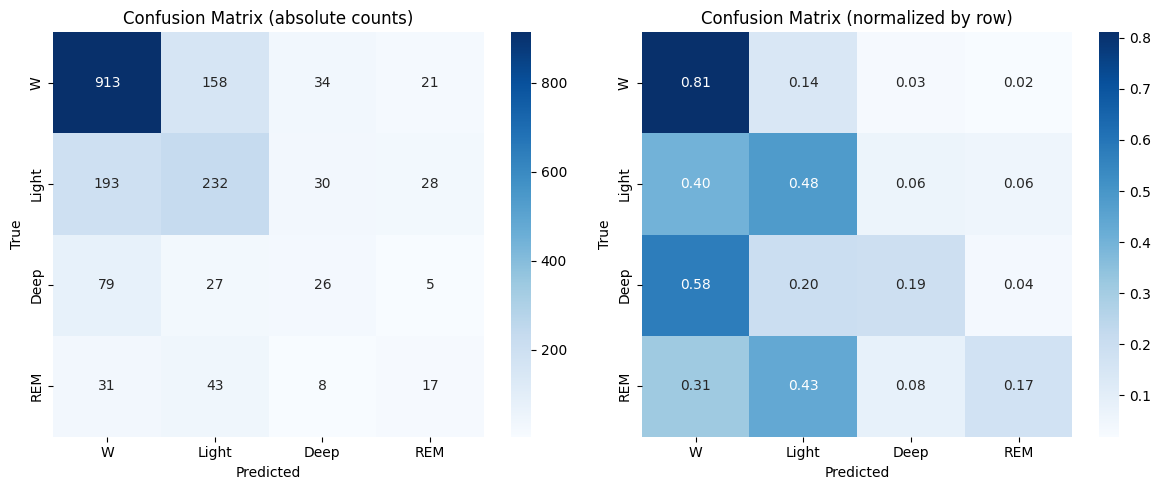

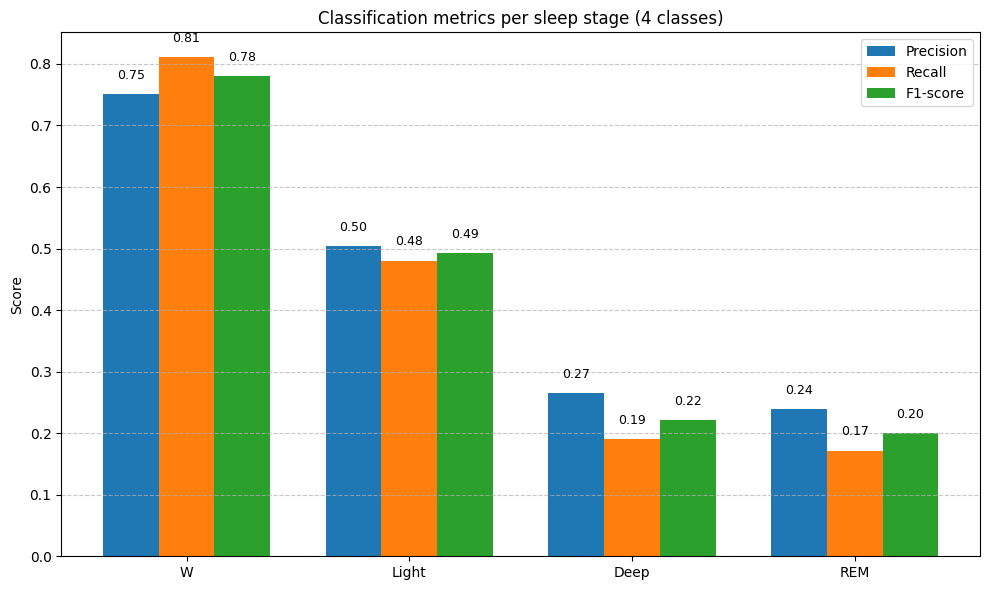

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


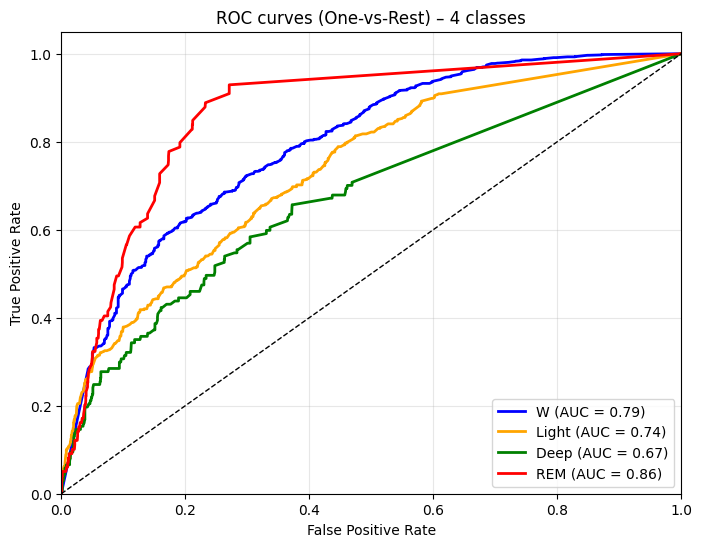

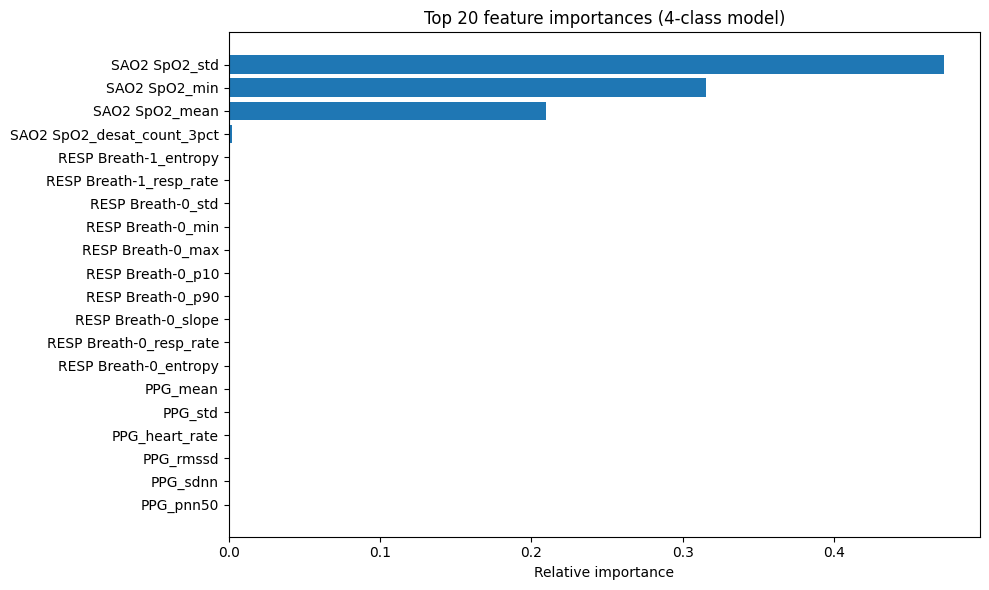

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import numpy as np

# Названия классов для 4 стадий
class_names = ['W', 'Light', 'Deep', 'REM']
n_classes = len(class_names)

# 1. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (absolute counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized by row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

# 2. Precision, Recall, F1 по классам
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('Score')
ax.set_title('Classification metrics per sleep stage (4 classes)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 3. ROC-кривые (One-vs-Rest)
if hasattr(pipeline, 'predict_proba'):
    y_score = pipeline.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))
    colors = ['blue', 'orange', 'green', 'red']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves (One-vs-Rest) – 4 classes')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Модель не поддерживает predict_proba.")

# 4. Важность признаков (RandomForest)
if hasattr(pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = pipeline.named_steps['classifier'].feature_importances_
    feature_names = X_all.columns
    indices = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 6))
    plt.title('Top 20 feature importances (4-class model)')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Модель не предоставляет важность признаков.")